In [1]:
!pip -q install -U tensorflow tensorflow-federated

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 50.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 45.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.3/887.3 kB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.8/180.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is in

Saving Huntington Disease Dataset.zip to Huntington Disease Dataset.zip

Running FAST ShapFed for: Category
round 1 test acc: 0.4966 val acc: 0.4829
round 2 test acc: 0.4967 val acc: 0.4829
round 3 test acc: 0.4967 val acc: 0.4827
round 4 test acc: 0.4967 val acc: 0.4829
round 5 test acc: 0.4964 val acc: 0.4827


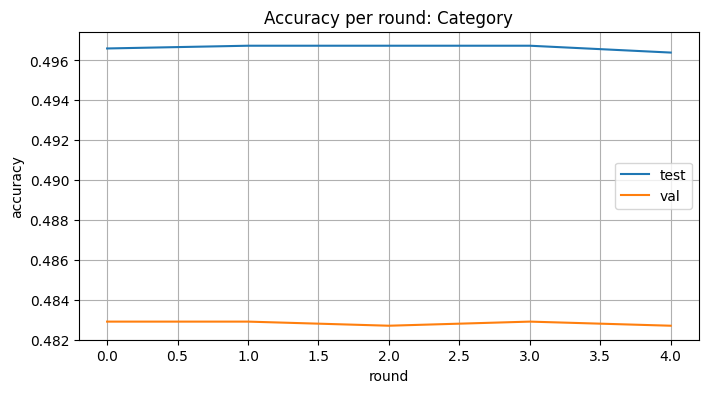

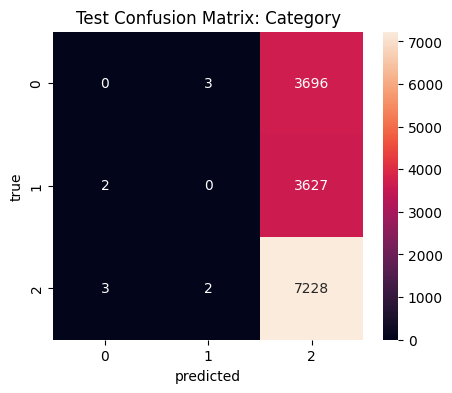

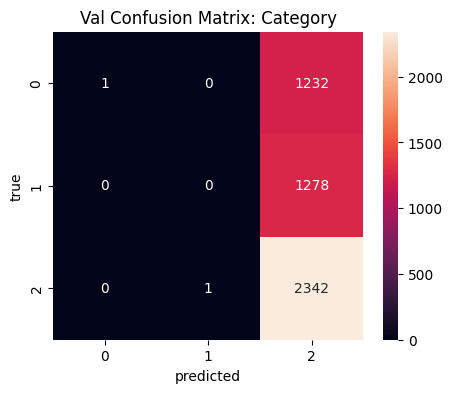


Running FAST ShapFed for: Motor_Symptoms
round 1 test acc: 0.3357 val acc: 0.3325
round 2 test acc: 0.33 val acc: 0.3302
round 3 test acc: 0.3327 val acc: 0.3302
round 4 test acc: 0.3294 val acc: 0.3352
round 5 test acc: 0.3265 val acc: 0.3319


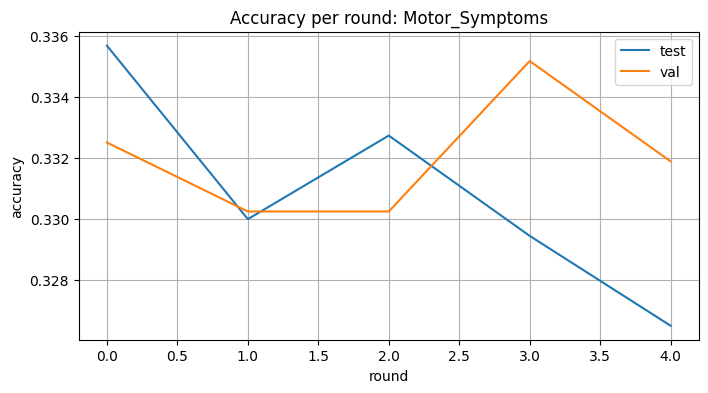

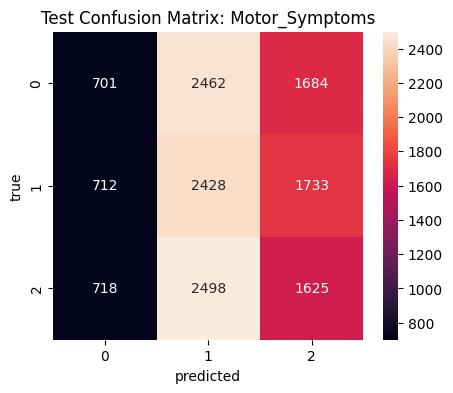

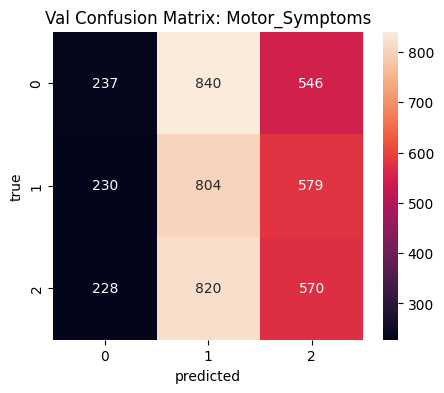


Running FAST ShapFed for: Disease_Stage
round 1 test acc: 0.2489 val acc: 0.2513
round 2 test acc: 0.249 val acc: 0.2458
round 3 test acc: 0.248 val acc: 0.247
round 4 test acc: 0.2462 val acc: 0.2437
round 5 test acc: 0.2449 val acc: 0.2499


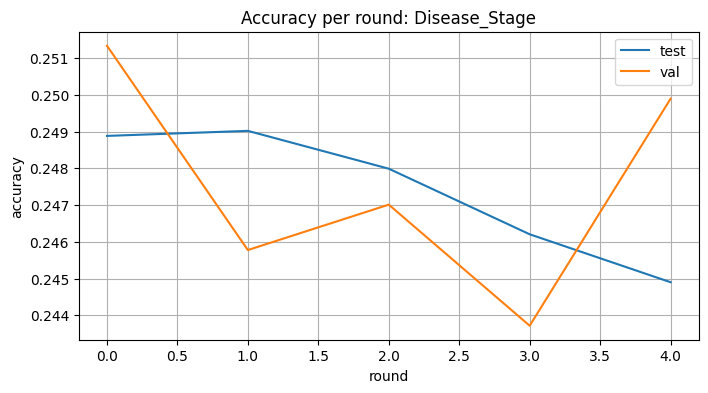

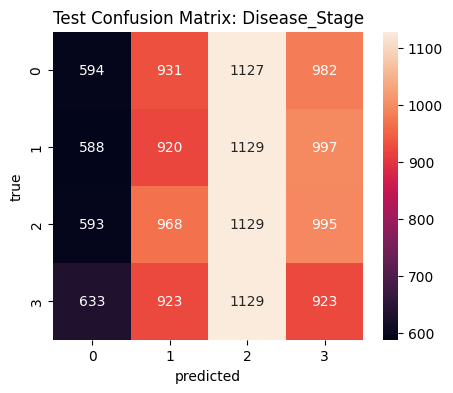

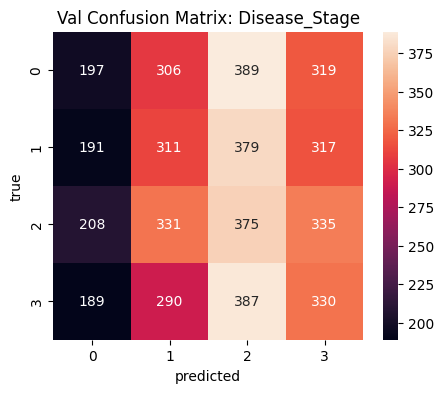


Final Comparison Table
           target  test_accuracy  test_precision  test_recall   test_f1  \
0        Category       0.496394        0.246747     0.496394  0.329638   
1  Motor_Symptoms       0.326489        0.326634     0.326489  0.308754   
2   Disease_Stage       0.244901        0.244906     0.244901  0.241973   

   val_accuracy  
0      0.482695  
1      0.331891  
2      0.249897  

Overall Test Accuracy: 0.3559
Overall Validation Accuracy: 0.3548


In [4]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, "r") as z:
    z.extractall("/content/")

csv_files = [f for f in os.listdir("/content/") if f.endswith(".csv")]
csv_path = os.path.join("/content/", csv_files[0])

df = pd.read_csv(csv_path)
df = df.ffill()

df = df.drop(columns=[
    "Patient_ID",
    "Function",
    "Effect",
    "Gene/Factor",
    "Chromosome_Location",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence"
], errors="ignore")

for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

def build_model(num_features, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(num_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

def split_into_clients(X, y, num_clients=3):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    shards = np.array_split(idx, num_clients)
    return [(X[s], y[s]) for s in shards]

def get_weights(model):
    return [w.copy() for w in model.get_weights()]

def set_weights(model, weights):
    model.set_weights(weights)

def subtract_weights(a, b):
    return [ai - bi for ai, bi in zip(a, b)]

def add_weights(a, b):
    return [ai + bi for ai, bi in zip(a, b)]

def scale_weights(w, s):
    return [x * s for x in w]

def predict_classes(model, X):
    probs = model.predict(X, verbose=0, batch_size=1024)
    return np.argmax(probs, axis=1)

def utility_accuracy(model, X, y):
    preds = predict_classes(model, X)
    return float(accuracy_score(y, preds))

def shapley_weights_fast(base_weights, updates, X_eval, y_eval, permutations=8):
    n = len(updates)
    contrib = np.zeros(n, dtype=np.float64)

    # build once and reuse
    temp_model = build_model(X_eval.shape[1], int(np.max(y_eval)) + 1)

    for _ in range(permutations):
        order = np.random.permutation(n)

        w = [bw.copy() for bw in base_weights]
        set_weights(temp_model, w)
        prev_u = utility_accuracy(temp_model, X_eval, y_eval)

        for i in order:
            w = add_weights(w, updates[i])
            set_weights(temp_model, w)
            new_u = utility_accuracy(temp_model, X_eval, y_eval)
            contrib[i] += (new_u - prev_u)
            prev_u = new_u

    contrib = np.maximum(contrib, 0)
    if float(contrib.sum()) == 0.0:
        return np.ones(n, dtype=np.float64) / float(n)
    return contrib / float(contrib.sum())

def plot_confusion(y_true, y_pred, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.show()

def plot_accuracy_curve(test_acc, val_acc, title):
    plt.figure(figsize=(8,4))
    plt.plot(test_acc, label="test")
    plt.plot(val_acc, label="val")
    plt.title(title)
    plt.xlabel("round")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

def run_shapfed_fast(target):
    print("\nRunning FAST ShapFed for:", target)

    y = df[target].astype(int)
    X = df.drop(columns=["Category","Motor_Symptoms","Disease_Stage"], errors="ignore")

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)

    y_train = y_train.to_numpy().astype(np.int32)
    y_test = y_test.to_numpy().astype(np.int32)
    y_val = y_val.to_numpy().astype(np.int32)

    # small eval subset for Shapley utility
    eval_n = min(600, len(X_val))
    idx = np.random.choice(len(X_val), size=eval_n, replace=False)
    X_eval = X_val[idx]
    y_eval = y_val[idx]

    num_features = X_train.shape[1]
    num_classes = int(np.max(y_train)) + 1

    # speed settings
    NUM_CLIENTS = 3
    ROUNDS = 5
    CLIENT_EPOCHS = 1
    BATCH_SIZE = 128
    PERMS = 8

    clients = split_into_clients(X_train, y_train, num_clients=NUM_CLIENTS)

    global_model = build_model(num_features, num_classes)
    global_weights = get_weights(global_model)

    test_hist, val_hist = [], []

    for rnd in range(ROUNDS):
        updates = []

        # local training for each client
        for Xc, yc in clients:
            local = build_model(num_features, num_classes)
            set_weights(local, global_weights)
            local.fit(Xc, yc, epochs=CLIENT_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            updates.append(subtract_weights(get_weights(local), global_weights))

        # ShapFed weights using fast Monte Carlo Shapley
        shap_w = shapley_weights_fast(global_weights, updates, X_eval, y_eval, permutations=PERMS)

        # aggregate weighted updates
        agg = None
        for i, up in enumerate(updates):
            w_up = scale_weights(up, float(shap_w[i]))
            agg = w_up if agg is None else add_weights(agg, w_up)

        global_weights = add_weights(global_weights, agg)
        set_weights(global_model, global_weights)

        # evaluate
        test_pred = predict_classes(global_model, X_test)
        val_pred = predict_classes(global_model, X_val)

        test_acc = accuracy_score(y_test, test_pred)
        val_acc = accuracy_score(y_val, val_pred)

        test_hist.append(test_acc)
        val_hist.append(val_acc)

        print("round", rnd+1, "test acc:", round(test_acc,4), "val acc:", round(val_acc,4))

    plot_accuracy_curve(test_hist, val_hist, "Accuracy per round: " + target)
    plot_confusion(y_test, test_pred, "Test Confusion Matrix: " + target)
    plot_confusion(y_val, val_pred, "Val Confusion Matrix: " + target)

    return {
        "target": target,
        "test_accuracy": float(test_acc),
        "test_precision": float(precision_score(y_test, test_pred, average="weighted", zero_division=0)),
        "test_recall": float(recall_score(y_test, test_pred, average="weighted", zero_division=0)),
        "test_f1": float(f1_score(y_test, test_pred, average="weighted", zero_division=0)),
        "val_accuracy": float(val_acc)
    }

results = []
for t in ["Category","Motor_Symptoms","Disease_Stage"]:
    results.append(run_shapfed_fast(t))

results_df = pd.DataFrame(results)
print("\nFinal Comparison Table")
print(results_df)

print("\nOverall Test Accuracy:", round(float(results_df["test_accuracy"].mean()), 4))
print("Overall Validation Accuracy:", round(float(results_df["val_accuracy"].mean()), 4))


